In [1]:
# Verificación del entorno
import sys
from pathlib import Path

try:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        f"Falta la librería '{error.name}'. Instálela en el entorno y reinicie el kernel."
    ) from error

print("Intérprete:", sys.executable)
if ".venv" not in sys.executable:
    print("AVISO: este no parece el Python del entorno virtual (.venv).")

RUTA_VERIFICACION = "../dataset/train.csv"
if not Path(RUTA_VERIFICACION).exists():
    raise FileNotFoundError(f"No se encuentra {RUTA_VERIFICACION}. El notebook debe estar en la carpeta Momento1.")
print("Datos: encontrados en", RUTA_VERIFICACION)

Intérprete: /home/breiner/Development/data_analysis/Data-analysis/Archivo/Archivo/.venv/bin/python
Datos: encontrados en ../dataset/train.csv


In [2]:
# Carga de datos
df = pd.read_csv(RUTA_VERIFICACION)
df_original = df.copy()  # término de comparación para el antes/después
print(f"Filas y columnas: {df.shape}")

Filas y columnas: (8523, 12)


## Traducción al español

In [3]:
# Traducción de los nombres de las columnas
df = df.rename(columns={
    'Item_Identifier': 'id_producto',
    'Item_Weight': 'peso_producto',
    'Item_Fat_Content': 'contenido_grasa',
    'Item_Visibility': 'visibilidad_producto',
    'Item_Type': 'tipo_producto',
    'Item_MRP': 'precio_maximo',
    'Outlet_Identifier': 'id_tienda',
    'Outlet_Establishment_Year': 'anio_apertura',
    'Outlet_Size': 'tamano_tienda',
    'Outlet_Location_Type': 'tipo_ubicacion',
    'Outlet_Type': 'tipo_tienda',
    'Item_Outlet_Sales': 'ventas_totales',
})

# Traducción de los valores. Cada variante se traduce a su equivalente en español,
# incluidas las mal escritas (LF, low fat, reg): se unifican más adelante, en la limpieza.
df['contenido_grasa'] = df['contenido_grasa'].replace({
    'Low Fat': 'Bajo en Grasa',
    'low fat': 'bajo en grasa',
    'LF': 'BG',
    'Regular': 'Regular',
    'reg': 'reg',
})

df['tipo_producto'] = df['tipo_producto'].replace({
    'Fruits and Vegetables': 'Frutas y verduras',
    'Snack Foods': 'Snacks',
    'Household': 'Hogar',
    'Frozen Foods': 'Congelados',
    'Dairy': 'Lácteos',
    'Canned': 'Enlatados',
    'Baking Goods': 'Insumos de repostería',
    'Health and Hygiene': 'Salud e higiene',
    'Soft Drinks': 'Bebidas sin alcohol',
    'Meat': 'Carnes',
    'Breads': 'Panes',
    'Hard Drinks': 'Licores',
    'Others': 'Otros',
    'Starchy Foods': 'Alimentos con almidón',
    'Breakfast': 'Desayuno',
    'Seafood': 'Mariscos',
})

df['tamano_tienda'] = df['tamano_tienda'].replace({
    'Small': 'Pequeña',
    'Medium': 'Mediana',
    'High': 'Grande',
})

df['tipo_ubicacion'] = df['tipo_ubicacion'].replace({
    'Tier 1': 'Nivel 1',
    'Tier 2': 'Nivel 2',
    'Tier 3': 'Nivel 3',
})

df['tipo_tienda'] = df['tipo_tienda'].replace({
    'Grocery Store': 'Tienda de abarrotes',
    'Supermarket Type1': 'Supermercado tipo 1',
    'Supermarket Type2': 'Supermercado tipo 2',
    'Supermarket Type3': 'Supermercado tipo 3',
})

In [4]:
# Primeras filas
df.head()

,id_producto,peso_producto,contenido_grasa,visibilidad_producto,tipo_producto,precio_maximo,id_tienda,anio_apertura,tamano_tienda,tipo_ubicacion,tipo_tienda,ventas_totales
0,FDA15,9.30,Bajo en Grasa,0.016047,Lácteos,249.8092,OUT049,1999,Mediana,Nivel 1,Supermercado tipo 1,3735.1380
1,DRC01,5.92,Regular,0.019278,Bebidas sin alcohol,48.2692,OUT018,2009,Mediana,Nivel 3,Supermercado tipo 2,443.4228
2,FDN15,17.50,Bajo en Grasa,0.016760,Carnes,141.6180,OUT049,1999,Mediana,Nivel 1,Supermercado tipo 1,2097.2700
3,FDX07,19.20,Regular,0.000000,Frutas y verduras,182.0950,OUT010,1998,NaN,Nivel 3,Tienda de abarrotes,732.3800
4,NCD19,8.93,Bajo en Grasa,0.000000,Hogar,53.8614,OUT013,1987,Grande,Nivel 3,Supermercado tipo 1,994.7052


## Estructura y tipos de datos

Antes de limpiar se mira qué trae cada columna: tipo, nulos y cuántas categorías distintas tiene cada columna de texto.

In [5]:
df.info()

print("\nColumnas de texto con pocas categorías (candidatas a 'category'):")
print(df.select_dtypes(include=['object', 'string']).nunique().sort_values())

<class 'pandas.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_producto           8523 non-null   str    
 1   peso_producto         7060 non-null   float64
 2   contenido_grasa       8523 non-null   str    
 3   visibilidad_producto  8523 non-null   float64
 4   tipo_producto         8523 non-null   str    
 5   precio_maximo         8523 non-null   float64
 6   id_tienda             8523 non-null   str    
 7   anio_apertura         8523 non-null   int64  
 8   tamano_tienda         6113 non-null   str    
 9   tipo_ubicacion        8523 non-null   str    
 10  tipo_tienda           8523 non-null   str    
 11  ventas_totales        8523 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 799.2 KB

Columnas de texto con pocas categorías (candidatas a 'category'):
tamano_tienda         3
tipo_ubicacion        3
tipo_tienda    

**Decisión sobre los tipos:**
- `anio_apertura` es entero: se usa como número (antigüedad de la tienda, correlación). No se convierte a fecha porque solo trae el año.
- `peso_producto`, `visibilidad_producto`, `precio_maximo` y `ventas_totales` son decimales: son medidas continuas.
- `id_producto` e `id_tienda` son texto: son códigos, no se suman ni se promedian.
- Las demás son categorías en texto. `contenido_grasa` muestra 5 categorías, cuando deberían ser 2: las variantes se unifican en la normalización que sigue.
- Convertirlas a `category` solo ahorraría memoria y con 8.523 filas no hace falta.

### Validación de normalización y formato (Mayúsculas / Minúsculas)
Se evalúan todas las columnas categóricas (`str`/`object`) para verificar:
1. **Rojo (🔴)**: Inconsistencias críticas (variantes duplicadas con diferente escritura como `Bajo en Grasa` vs `bajo en grasa`).
2. **Amarillo (🟡)**: Mezcla de mayúsculas y minúsculas (columnas con letras minúsculas pendientes de normalizar a **MAYÚSCULAS** en la siguiente sección).
3. **Verde (🟢)**: Columnas que ya se encuentran 100% estandarizadas en **MAYÚSCULAS**.

In [6]:
# Verificación de normalización y formato (Mayúsculas / Minúsculas) en columnas de texto
columnas_str = df.select_dtypes(include=['object', 'string']).columns

# Códigos de color ANSI para Jupyter y terminal
CLR_RESET = '\033[0m'
CLR_BOLD = '\033[1m'
CLR_RED = '\033[91m'
CLR_GREEN = '\033[92m'
CLR_YELLOW = '\033[93m'

resumen_normalizacion = []

print("=" * 85)
print(f"{CLR_BOLD}VERIFICACIÓN DE NORMALIZACIÓN Y FORMATO (MAYÚSCULAS / MINÚSCULAS){CLR_RESET}")
print("=" * 85)

for col in columnas_str:
    serie_limpia = df[col].dropna().astype(str)
    total_validos = len(serie_limpia)
    
    # 1. Espacios en blanco al inicio o al final
    espacios_extra = (serie_limpia != serie_limpia.str.strip()).sum()
    
    # 2. Detección de variantes duplicadas por capitalización
    agrupado = serie_limpia.groupby(serie_limpia.str.strip().str.lower())
    variantes_caso = agrupado.unique()[agrupado.nunique() > 1]
    tiene_variantes_duplicadas = len(variantes_caso) > 0
    
    # 3. Detección de mezcla de mayúsculas y minúsculas (valores que no están 100% en MAYÚSCULAS)
    con_minusculas = serie_limpia.str.contains(r'[a-z]').sum()
    es_100_mayusculas = (con_minusculas == 0)
    
    # Clasificación por colores según el estado
    if tiene_variantes_duplicadas or espacios_extra > 0:
        estado_icono = "🔴 Inconsistencias de variantes"
        color = CLR_RED
        etiqueta = "INCONSISTENCIAS CRÍTICAS"
    elif not es_100_mayusculas:
        estado_icono = "🟡 Mezcla de mayúsculas/minúsculas"
        color = CLR_YELLOW
        etiqueta = "PENDIENTE NORMALIZAR A MAYÚSCULAS"
    else:
        estado_icono = "🟢 100% MAYÚSCULAS"
        color = CLR_GREEN
        etiqueta = "NORMALIZADA (MAYÚSCULAS)"
        
    resumen_normalizacion.append({
        'Columna': col,
        'Estado': estado_icono,
        '¿100% Mayúsculas?': '🟢 Sí' if es_100_mayusculas else '🟡 No',
        '¿Variantes duplicadas?': '🔴 Sí' if tiene_variantes_duplicadas else '🟢 No',
        'Registros con minúsculas/mezcla': con_minusculas,
        'Valores únicos': df[col].nunique(),
        'Nulos': df[col].isnull().sum()
    })
    
    print(f"\n{color}{CLR_BOLD}● Columna: '{col}' -> [{etiqueta}]{CLR_RESET}")
    
    if tiene_variantes_duplicadas or espacios_extra > 0:
        if espacios_extra > 0:
            print(f"   {CLR_RED}⚠️ Se encontraron {espacios_extra} registros con espacios sobrantes al inicio/final.{CLR_RESET}")
        if tiene_variantes_duplicadas:
            print(f"   {CLR_RED}⚠️ Variantes duplicadas detectadas (diferente capitalización para el mismo concepto):{CLR_RESET}")
            for base, lista_variantes in variantes_caso.items():
                print(f"     -> Concepto base (en minúsculas): '{base}'")
                conteos = serie_limpia[serie_limpia.str.strip().str.lower() == base].value_counts()
                for var, cant in conteos.items():
                    pct = (cant / total_validos) * 100
                    print(f"        - '{var}': {cant} registros ({pct:.2f}%)")
        print(f"\n   -> Distribución de valores en '{col}':")
        frecuencias = df[col].value_counts(dropna=False).to_frame(name='Conteo')
        frecuencias['Porcentaje'] = (frecuencias['Conteo'] / len(df) * 100).round(2).astype(str) + '%'
        print(frecuencias.to_string())
        
    elif not es_100_mayusculas:
        pct_min = (con_minusculas / total_validos) * 100
        print(f"   {CLR_YELLOW}🟡 Contiene mezcla de mayúsculas y minúsculas: {con_minusculas} registros ({pct_min:.1f}%).{CLR_RESET}")
        print(f"   {CLR_YELLOW}   -> Requiere conversión a MAYÚSCULAS en la siguiente sección.{CLR_RESET}")
        print(f"   -> Muestra de valores actuales: {list(serie_limpia.unique()[:5])}")
        
    else:
        print(f"   {CLR_GREEN}🟢 Todos los registros ({total_validos}) ya están en formato MAYÚSCULAS uniforme.{CLR_RESET}")

print("\n" + "=" * 85)
print(f"{CLR_BOLD}RESUMEN GENERAL DE NORMALIZACIÓN{CLR_RESET}")
print("=" * 85)
df_resumen = pd.DataFrame(resumen_normalizacion)
print(df_resumen.to_string(index=False))

VERIFICACIÓN DE NORMALIZACIÓN Y FORMATO (MAYÚSCULAS / MINÚSCULAS)



● Columna: 'id_producto' -> [NORMALIZADA (MAYÚSCULAS)]
   🟢 Todos los registros (8523) ya están en formato MAYÚSCULAS uniforme.

● Columna: 'contenido_grasa' -> [INCONSISTENCIAS CRÍTICAS]
   ⚠️ Variantes duplicadas detectadas (diferente capitalización para el mismo concepto):
     -> Concepto base (en minúsculas): 'bajo en grasa'
        - 'Bajo en Grasa': 5089 registros (59.71%)
        - 'bajo en grasa': 112 registros (1.31%)

   -> Distribución de valores en 'contenido_grasa':
                 Conteo Porcentaje
contenido_grasa                   
Bajo en Grasa      5089     59.71%
Regular            2889      33.9%
BG                  316      3.71%
reg                 117      1.37%
bajo en grasa       112      1.31%

● Columna: 'tipo_producto' -> [PENDIENTE NORMALIZAR A MAYÚSCULAS]
   🟡 Contiene mezcla de mayúsculas y minúsculas: 8523 registros (100.0%).
      -> Requiere conversión a MAYÚSCULAS en la siguiente sección.
   -> Muestra de valores actuales: ['Lácteos', 'Bebidas sin a


● Columna: 'tamano_tienda' -> [PENDIENTE NORMALIZAR A MAYÚSCULAS]
   🟡 Contiene mezcla de mayúsculas y minúsculas: 6113 registros (100.0%).
      -> Requiere conversión a MAYÚSCULAS en la siguiente sección.
   -> Muestra de valores actuales: ['Mediana', 'Grande', 'Pequeña']

● Columna: 'tipo_ubicacion' -> [PENDIENTE NORMALIZAR A MAYÚSCULAS]
   🟡 Contiene mezcla de mayúsculas y minúsculas: 8523 registros (100.0%).
      -> Requiere conversión a MAYÚSCULAS en la siguiente sección.
   -> Muestra de valores actuales: ['Nivel 1', 'Nivel 3', 'Nivel 2']

● Columna: 'tipo_tienda' -> [PENDIENTE NORMALIZAR A MAYÚSCULAS]
   🟡 Contiene mezcla de mayúsculas y minúsculas: 8523 registros (100.0%).
      -> Requiere conversión a MAYÚSCULAS en la siguiente sección.
   -> Muestra de valores actuales: ['Supermercado tipo 1', 'Supermercado tipo 2', 'Tienda de abarrotes', 'Supermercado tipo 3']

RESUMEN GENERAL DE NORMALIZACIÓN
        Columna                            Estado ¿100% Mayúsculas? ¿Variantes

### Normalización de columnas de texto a MAYÚSCULAS (Sin tildes y Ñ -> N)
Se unifican las categorías de `contenido_grasa` (`BAJO EN GRASA` y `REGULAR`) y se estandarizan todas las variables de texto:
1. Conversión completa a **MAYÚSCULAS** y eliminación de espacios en blanco en los extremos.
2. **Eliminación de tildes/acentos** (ej. `LÁCTEOS` -> `LACTEOS`, `REPOSTERÍA` -> `REPOSTERIA`).
3. **Reemplazo de la letra Ñ por N** (ej. `PEQUEÑA` -> `PEQUENA`).

In [7]:
import unicodedata

# Función para normalizar texto: mayúsculas, sin tildes, Ñ -> N y sin espacios externos
def normalizar_texto(val):
    if pd.isna(val):
        return val
    # 1. Reemplazo de Ñ y ñ por N
    s = str(val).replace('Ñ', 'N').replace('ñ', 'N')
    # 2. Eliminación de tildes y diacríticos mediante descomposición Unicode (NFKD)
    s = ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c))
    # 3. Mayúsculas sostenidas y eliminación de espacios en los extremos
    return s.strip().upper()

# 1. Unificar variantes y abreviaturas en 'contenido_grasa'
df['contenido_grasa'] = df['contenido_grasa'].replace({
    'Bajo en Grasa': 'BAJO EN GRASA',
    'bajo en grasa': 'BAJO EN GRASA',
    'BG': 'BAJO EN GRASA',
    'Regular': 'REGULAR',
    'reg': 'REGULAR',
})

# 2. Aplicar normalización (mayúsculas, sin tildes, Ñ -> N) a todas las columnas de texto
columnas_str = df.select_dtypes(include=['object', 'string']).columns
for col in columnas_str:
    df[col] = df[col].apply(normalizar_texto)

print("=" * 80)
print("NORMALIZACIÓN A MAYÚSCULAS (SIN TILDES Y Ñ -> N) COMPLETADA")
print("=" * 80)

print("\nDistribución final de 'contenido_grasa':")
print(df['contenido_grasa'].value_counts(dropna=False).to_frame(name='Conteo'))

print("\nVerificación de formato en todas las columnas:")
for col in columnas_str:
    s = df[col].dropna()
    con_tildes_o_enie = s.str.contains(r'[áéíóúÁÉÍÓÚñÑüÜ]').sum()
    con_minusculas = s.str.contains(r'[a-z]').sum()
    print(f"  • {col:<20}: Tildes/Ñ: {con_tildes_o_enie} | Minúsculas: {con_minusculas} | Valores únicos: {s.nunique()}")

print("\nMuestra de valores transformados (sin tildes y con Ñ -> N):")
print("  • tamano_tienda:", list(df['tamano_tienda'].dropna().unique()))
print("  • tipo_producto (extracto):", list(df['tipo_producto'].unique()[:4]))

df.head()

NORMALIZACIÓN A MAYÚSCULAS (SIN TILDES Y Ñ -> N) COMPLETADA

Distribución final de 'contenido_grasa':
                 Conteo
contenido_grasa        
BAJO EN GRASA      5517
REGULAR            3006

Verificación de formato en todas las columnas:
  • id_producto         : Tildes/Ñ: 0 | Minúsculas: 0 | Valores únicos: 1559
  • contenido_grasa     : Tildes/Ñ: 0 | Minúsculas: 0 | Valores únicos: 2
  • tipo_producto       : Tildes/Ñ: 0 | Minúsculas: 0 | Valores únicos: 16
  • id_tienda           : Tildes/Ñ: 0 | Minúsculas: 0 | Valores únicos: 10
  • tamano_tienda       : Tildes/Ñ: 0 | Minúsculas: 0 | Valores únicos: 3
  • tipo_ubicacion      : Tildes/Ñ: 0 | Minúsculas: 0 | Valores únicos: 3
  • tipo_tienda         : Tildes/Ñ: 0 | Minúsculas: 0 | Valores únicos: 4

Muestra de valores transformados (sin tildes y con Ñ -> N):
  • tamano_tienda: ['MEDIANA', 'GRANDE', 'PEQUENA']
  • tipo_producto (extracto): ['LACTEOS', 'BEBIDAS SIN ALCOHOL', 'CARNES', 'FRUTAS Y VERDURAS']


,id_producto,peso_producto,contenido_grasa,visibilidad_producto,tipo_producto,precio_maximo,id_tienda,anio_apertura,tamano_tienda,tipo_ubicacion,tipo_tienda,ventas_totales
0,FDA15,9.30,BAJO EN GRASA,0.016047,LACTEOS,249.8092,OUT049,1999,MEDIANA,NIVEL 1,SUPERMERCADO TIPO 1,3735.1380
1,DRC01,5.92,REGULAR,0.019278,BEBIDAS SIN ALCOHOL,48.2692,OUT018,2009,MEDIANA,NIVEL 3,SUPERMERCADO TIPO 2,443.4228
2,FDN15,17.50,BAJO EN GRASA,0.016760,CARNES,141.6180,OUT049,1999,MEDIANA,NIVEL 1,SUPERMERCADO TIPO 1,2097.2700
3,FDX07,19.20,REGULAR,0.000000,FRUTAS Y VERDURAS,182.0950,OUT010,1998,NaN,NIVEL 3,TIENDA DE ABARROTES,732.3800
4,NCD19,8.93,BAJO EN GRASA,0.000000,HOGAR,53.8614,OUT013,1987,GRANDE,NIVEL 3,SUPERMERCADO TIPO 1,994.7052


In [8]:
# Nulos por columna
df.isnull().sum()

id_producto                0
peso_producto           1463
contenido_grasa            0
visibilidad_producto       0
tipo_producto              0
precio_maximo              0
id_tienda                  0
anio_apertura              0
tamano_tienda           2410
tipo_ubicacion             0
tipo_tienda                0
ventas_totales             0
dtype: int64

## Duplicados

Una fila es un producto en una tienda: (`id_producto`, `id_tienda`) debería identificarla. Se revisan los duplicados completos y también los de esa llave, porque un mismo producto repetido en la misma tienda sería un error aunque cambie otra columna.

In [9]:
# Duplicados
print("Filas completamente duplicadas:", df.duplicated().sum())
print("Duplicados por (id_producto, id_tienda):", df.duplicated(subset=['id_producto', 'id_tienda']).sum())

Filas completamente duplicadas: 0
Duplicados por (id_producto, id_tienda): 0


### Diagnóstico de Valores Faltantes y Significado para el Negocio

Para tomar decisiones rigurosas, medimos la cantidad exacta de faltantes, su **porcentaje de representatividad** sobre las 8.523 filas y el **significado comercial** de cada variable dentro de la cadena de tiendas.

In [10]:
# ==============================================================================
# DIAGNÓSTICO: CANTIDAD DE NULOS, PORCENTAJES Y SIGNIFICADO PARA EL NEGOCIO
# ==============================================================================
# 1. Diccionario con el significado y rol de cada columna para el negocio
significado_negocio = {
    'id_producto': 'Código único de identificación de cada artículo en el catálogo de la cadena.',
    'peso_producto': 'Peso físico del producto en kg. Relevante para logística/fletes; no influye en la decisión de compra.',
    'contenido_grasa': 'Nivel de grasa (Bajo en grasa / Regular). Refleja preferencias de salud y dietéticas del cliente.',
    'visibilidad_producto': 'Porcentaje de área de góndola asignada al producto en estantería frente al total de la tienda.',
    'tipo_producto': 'Categoría comercial del artículo (16 familias). Define la oferta y rotación del portafolio.',
    'precio_maximo': 'Precio de venta al público sugerido/máximo (MRP). Factor principal del ticket y margen monetario.',
    'id_tienda': 'Código de la sucursal (10 tiendas). Permite evaluar y comparar el rendimiento por punto de venta.',
    'anio_apertura': 'Año en que inició operaciones la sucursal (1985-2009). Mide madurez y trayectoria comercial.',
    'tamano_tienda': 'Dimensión física de la tienda (Pequeña, Mediana, Grande). Define capacidad de surtido y flujo de clientes.',
    'tipo_ubicacion': 'Clasificación socioeconómica de la ciudad/zona (Nivel 1, 2, 3). Refleja poder adquisitivo local.',
    'tipo_tienda': 'Formato del canal de venta (Abarrotes vs Supermercados 1, 2, 3). Explica la escala del negocio.',
    'ventas_totales': 'Ingresos brutos por producto en esa sucursal. Es la variable objetivo y KPI financiero principal.'
}

# 2. Construcción del DataFrame diagnóstico
df_diagnostico_nulos = pd.DataFrame({
    'Cantidad Nulos': df.isnull().sum(),
    'Porcentaje (%)': ((df.isnull().sum() / len(df)) * 100).round(2),
    'Qué representa para nuestro negocio': pd.Series(significado_negocio)
})

# 3. Mostrar columnas que contienen faltantes con detalle analítico
print("=" * 95)
print("RESUMEN DE COLUMNAS CON VALORES NULOS A TRATAR")
print("=" * 95)
faltantes_solo = df_diagnostico_nulos[df_diagnostico_nulos['Cantidad Nulos'] > 0].copy()
faltantes_solo['Porcentaje (%)'] = faltantes_solo['Porcentaje (%)'].apply(lambda x: f"{x:.2f}%")
display(faltantes_solo)

print("\n" + "=" * 95)
print("PANORAMA COMPLETO DEL DATASET (12 COLUMNAS)")
print("=" * 95)
df_diagnostico_mostrar = df_diagnostico_nulos.copy()
df_diagnostico_mostrar['Porcentaje (%)'] = df_diagnostico_mostrar['Porcentaje (%)'].apply(lambda x: f"{x:.2f}%")
pd.set_option('display.max_colwidth', None)
display(df_diagnostico_mostrar)

RESUMEN DE COLUMNAS CON VALORES NULOS A TRATAR


,Cantidad Nulos,Porcentaje (%),Qué representa para nuestro negocio
peso_producto,1463,17.17%,Peso físico del producto en kg. Relevante para...
tamano_tienda,2410,28.28%,"Dimensión física de la tienda (Pequeña, Median..."



PANORAMA COMPLETO DEL DATASET (12 COLUMNAS)


,Cantidad Nulos,Porcentaje (%),Qué representa para nuestro negocio
id_producto,0,0.00%,Código único de identificación de cada artículo en el catálogo de la cadena.
peso_producto,1463,17.17%,Peso físico del producto en kg. Relevante para logística/fletes; no influye en la decisión de compra.
contenido_grasa,0,0.00%,Nivel de grasa (Bajo en grasa / Regular). Refleja preferencias de salud y dietéticas del cliente.
visibilidad_producto,0,0.00%,Porcentaje de área de góndola asignada al producto en estantería frente al total de la tienda.
tipo_producto,0,0.00%,Categoría comercial del artículo (16 familias). Define la oferta y rotación del portafolio.
precio_maximo,0,0.00%,Precio de venta al público sugerido/máximo (MRP). Factor principal del ticket y margen monetario.
id_tienda,0,0.00%,Código de la sucursal (10 tiendas). Permite evaluar y comparar el rendimiento por punto de venta.
anio_apertura,0,0.00%,Año en que inició operaciones la sucursal (1985-2009). Mide madurez y trayectoria comercial.
tamano_tienda,2410,28.28%,"Dimensión física de la tienda (Pequeña, Mediana, Grande). Define capacidad de surtido y flujo de clientes."
tipo_ubicacion,0,0.00%,"Clasificación socioeconómica de la ciudad/zona (Nivel 1, 2, 3). Refleja poder adquisitivo local."


## Valores centinela: `visibilidad_producto` = 0

La visibilidad es el porcentaje de góndola que ocupa el producto. Un producto que **sí tiene ventas** no puede ocupar 0 %: el cero es un faltante disfrazado. Antes de decidir, se mira cuántos son, si hay ventas en esas filas y si se concentran en alguna tienda.

In [11]:
# Diagnóstico del cero
ceros = df['visibilidad_producto'] == 0
print(f"Filas con visibilidad = 0: {ceros.sum()} ({ceros.mean() * 100:.1f} %)")
print(f"De esas, con ventas > 0: {(df.loc[ceros, 'ventas_totales'] > 0).sum()}")
print(f"Visibilidad mínima de los valores no cero: {df.loc[~ceros, 'visibilidad_producto'].min():.6f}")

display(df[ceros].groupby('id_tienda').size().rename('ceros').to_frame().join(
    df.groupby('id_tienda').size().rename('filas')).assign(
    pct=lambda t: (t['ceros'] / t['filas'] * 100).round(1)))

print("\nVentas con visibilidad = 0 frente al resto:")
display(df.groupby(ceros)['ventas_totales'].agg(filas='size', media='mean', mediana='median').round(0)
          .rename(index={True: 'visibilidad = 0', False: 'visibilidad > 0'}))

Filas con visibilidad = 0: 526 (6.2 %)
De esas, con ventas > 0: 526
Visibilidad mínima de los valores no cero: 0.003575


,ceros,filas,pct
id_tienda,,,
OUT010,29,555,5.2
OUT013,59,932,6.3
OUT017,57,926,6.2
OUT018,65,928,7.0
OUT019,30,528,5.7
OUT027,60,935,6.4
OUT035,54,930,5.8
OUT045,58,929,6.2
OUT046,61,930,6.6



Ventas con visibilidad = 0 frente al resto:


,filas,media,mediana
visibilidad_producto,,,
visibilidad > 0,7997,2179.0,1794.0
visibilidad = 0,526,2223.0,1774.0


**Lectura del diagnóstico:** las 526 filas (6,2 %) tienen ventas mayores que cero y se reparten parejo entre las 10 tiendas (5 % a 7 % en cada una). No es un problema de una tienda en particular, sino un cero que se usó como "sin dato".

## Análisis de Correlación frente a las Ventas

Antes de decidir qué hacer con las columnas con faltantes, calculamos el **coeficiente de correlación de Pearson ($r$)** entre las variables numéricas y `ventas_totales`.

- **¿Qué representa $r$?** Mide la fuerza y dirección de la relación lineal entre dos variables (de $-1$ a $+1$).
  - **$r > 0,7$**: Fuerte | **$0,3 \le r \le 0,7$**: Moderada | **$r < 0,3$**: Débil o nula.
- **Objetivo:** Comprobar con evidencia matemática si `peso_producto` tiene alguna relación con los ingresos del negocio.

FUERZA DE ASOCIACIÓN LINEAL (r DE PEARSON) FRENTE A LAS VENTAS


,Correlación (r) con ventas_totales
ventas_totales,1.000
precio_maximo,0.568
peso_producto,0.014
anio_apertura,-0.049
visibilidad_producto,-0.129


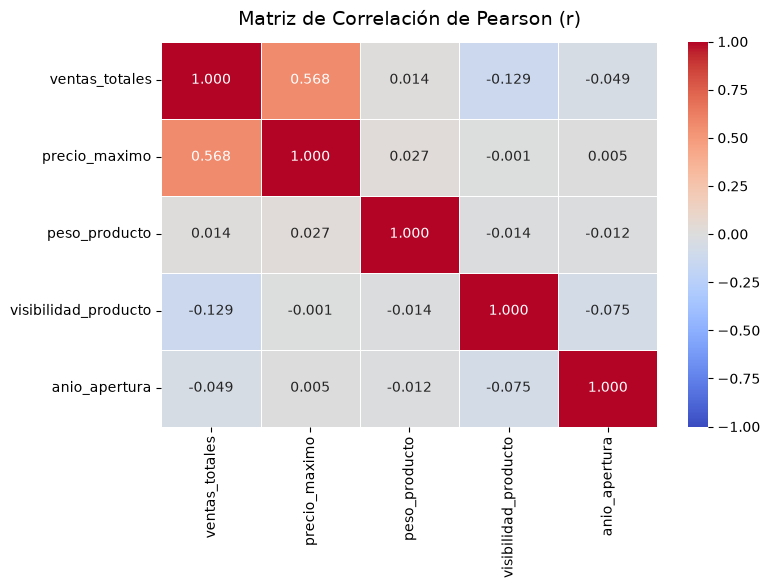


Lectura de resultados:
• precio_maximo (r = +0.568): Correlación moderada/fuerte positiva. A mayor precio, mayor venta.
• peso_producto (r = +0.014): Correlación prácticamente CERO. El peso físico no determina la venta.


In [12]:
# ==============================================================================
# 1. MATRIZ DE CORRELACIÓN Y ANÁLISIS DE 'r' FRENTE A 'ventas_totales'
# ==============================================================================
cols_num = ['ventas_totales', 'precio_maximo', 'peso_producto', 'visibilidad_producto', 'anio_apertura']
matriz_corr = df[cols_num].corr()

# Tabla ordenada de correlación con la variable objetivo
tabla_r = matriz_corr[['ventas_totales']].sort_values(by='ventas_totales', ascending=False)
tabla_r.columns = ['Correlación (r) con ventas_totales']

print("=" * 75)
print("FUERZA DE ASOCIACIÓN LINEAL (r DE PEARSON) FRENTE A LAS VENTAS")
print("=" * 75)
display(tabla_r.round(3))

# Gráfico: Mapa de calor (Heatmap) de correlaciones
plt.figure(figsize=(8, 5))
sns.heatmap(matriz_corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlación de Pearson (r)', fontsize=14, pad=12)
plt.show()

print("\nLectura de resultados:")
print(f"• precio_maximo (r = {matriz_corr.loc['precio_maximo', 'ventas_totales']:+.3f}): Correlación moderada/fuerte positiva. A mayor precio, mayor venta.")
print(f"• peso_producto (r = {matriz_corr.loc['peso_producto', 'ventas_totales']:+.3f}): Correlación prácticamente CERO. El peso físico no determina la venta.")

## ¿Los nulos y los ceros se comportan distinto en ventas?

Se aíslan solo las filas problemáticas (peso nulo, tamaño nulo, visibilidad en 0) y se comparan con el resto: ventas medias y medianas, y la correlación precio-ventas dentro de cada grupo. Si un grupo se comportara muy distinto, rellenarlo con valores del resto sería una mala idea.

In [13]:
# Nulos y ceros frente al resto
grupos = {
    'peso_producto nulo': df['peso_producto'].isna(),
    'tamano_tienda nulo': df['tamano_tienda'].isna(),
    'visibilidad_producto = 0': df['visibilidad_producto'] == 0,
}

filas = []
for nombre, mascara in grupos.items():
    g, resto = df[mascara], df[~mascara]
    filas.append({
        'grupo': nombre,
        'filas': int(mascara.sum()),
        'ventas media (grupo)': g['ventas_totales'].mean(),
        'ventas media (resto)': resto['ventas_totales'].mean(),
        'ventas mediana (grupo)': g['ventas_totales'].median(),
        'ventas mediana (resto)': resto['ventas_totales'].median(),
        'r precio-ventas (grupo)': g['precio_maximo'].corr(g['ventas_totales']),
        'r precio-ventas (resto)': resto['precio_maximo'].corr(resto['ventas_totales']),
    })
display(pd.DataFrame(filas).set_index('grupo').round(2))

# El cero distorsiona la correlación de la visibilidad con las ventas
con_visibilidad = df[df['visibilidad_producto'] > 0]
print("r(visibilidad, ventas) con todas las filas:", round(df['visibilidad_producto'].corr(df['ventas_totales']), 3))
print("r(visibilidad, ventas) sin los ceros:      ", round(con_visibilidad['visibilidad_producto'].corr(con_visibilidad['ventas_totales']), 3))

,filas,ventas media (grupo),ventas media (resto),ventas mediana (grupo),ventas mediana (resto),r precio-ventas (grupo),r precio-ventas (resto)
grupo,,,,,,,
peso_producto nulo,1463,2483.68,2118.63,1845.60,1789.67,0.45,0.62
tamano_tienda nulo,2410,1822.63,2322.69,1443.45,1928.16,0.53,0.59
visibilidad_producto = 0,526,2222.54,2178.58,1774.02,1794.33,0.58,0.57


r(visibilidad, ventas) con todas las filas: -0.129
r(visibilidad, ventas) sin los ceros:       -0.139


**Lectura:**
- **`visibilidad_producto` = 0:** las filas con cero venden igual que el resto (media 2.223 frente a 2.179; `r` precio-ventas 0,58 frente a 0,57). No son productos distintos: el cero es un dato que no se registró. Por eso rellenarlos con valores de los demás es razonable, y quitar los ceros apenas cambia la correlación visibilidad-ventas (-0,129 → -0,139).
- **`tamano_tienda` nulo:** vende bastante menos (media 1.823 frente a 2.323). No es azar: son tiendas completas, así que hay que mirar tienda por tienda (secciones siguientes) y no rellenar con un valor global.
- **`peso_producto` nulo:** se comporta casi como el resto, y el peso casi no se relaciona con las ventas. Se puede eliminar la columna sin perder información útil.

## ¿Dónde están los nulos de `tamano_tienda`?

El tamaño es una característica de la **tienda**, no de cada venta. Antes de decidir qué hacer, vemos si los 2.410 nulos están repartidos al azar o concentrados en algunas tiendas.

In [14]:
# ¿dónde están los nulos de 'tamano_tienda'?
nulos_por_tienda = (df.groupby('id_tienda')['tamano_tienda']
                      .agg(filas='size', nulos=lambda s: s.isna().sum()))
nulos_por_tienda['pct_nulos'] = (nulos_por_tienda['nulos'] / nulos_por_tienda['filas'] * 100).round(1)
display(nulos_por_tienda.sort_values('pct_nulos', ascending=False))

tiendas_con_nulos = nulos_por_tienda[nulos_por_tienda['nulos'] > 0]
print(f"Tiendas con nulos: {len(tiendas_con_nulos)} de {len(nulos_por_tienda)}")
print(f"¿Todas con 100% de nulos? {(tiendas_con_nulos['pct_nulos'] == 100).all()}")

,filas,nulos,pct_nulos
id_tienda,,,
OUT010,555,555,100.0
OUT017,926,926,100.0
OUT045,929,929,100.0
OUT013,932,0,0.0
OUT018,928,0,0.0
OUT019,528,0,0.0
OUT027,935,0,0.0
OUT035,930,0,0.0
OUT046,930,0,0.0


Tiendas con nulos: 3 de 10
¿Todas con 100% de nulos? True


## ¿El tamaño de la tienda cambia las ventas?

Comparamos la **media, la mediana y la moda** de `ventas_totales` por tamaño. El grupo `NULO` va al lado para ver a cuál se parece. Esto nos dice si la moda global (el valor más repetido de la columna) serviría para rellenar los nulos.

In [15]:
# ¿el tamaño de la tienda cambia las ventas?
df_tam = df.assign(tamano_tienda=df['tamano_tienda'].fillna('NULO'))

por_tamano = (df_tam.groupby('tamano_tienda')['ventas_totales']
                    .agg(tiendas=lambda s: df_tam.loc[s.index, 'id_tienda'].nunique(),
                         media='mean', mediana='median', moda=lambda s: s.mode()[0])
                    .round(0))
display(por_tamano)


,tiendas,media,mediana,moda
tamano_tienda,,,,
GRANDE,1,2299.0,2051.0,959.0
MEDIANA,3,2682.0,2251.0,1678.0
NULO,3,1823.0,1443.0,839.0
PEQUENA,3,1912.0,1545.0,1438.0


## ¿Qué tiendas se parecen a las 3 sin tamaño?

Una tabla por tienda (mínimo, media, mediana y máximo de `ventas_totales`; cada valor es un producto en esa tienda) y una comparación rápida **solo entre supermercados tipo 1**.

- `OUT010` (abarrotes) vende como `OUT019` (abarrotes, `PEQUENA`) y nada como los supermercados.
- `OUT017` y `OUT045` comparten tipo y ubicación con `OUT035` (`PEQUENA`).
- Dentro de supermercados tipo 1 el tamaño casi no cambia las ventas: las ventas **no confirman** el tamaño, así que para `OUT017` y `OUT045` es una hipótesis.

In [16]:
# Resumen por tienda y comparación dentro del mismo tipo de tienda
df_tam = df.assign(tamano_tienda=df['tamano_tienda'].fillna('NULO'))

# 1. Una fila por tienda: así se ve quién se parece a quién
por_tienda = (df_tam.groupby(['tipo_tienda', 'tipo_ubicacion', 'id_tienda', 'tamano_tienda'])['ventas_totales']
                    .agg(minimo='min', media='mean', mediana='median', maximo='max')
                    .round(0).reset_index())
display(por_tienda)

# 2. Solo supermercados tipo 1: ¿el tamaño cambia las ventas?
sm1 = df_tam[df_tam['tipo_tienda'] == 'SUPERMERCADO TIPO 1']
display(sm1.groupby('tamano_tienda')['ventas_totales'].agg(media='mean', mediana='median').round(0))

,tipo_tienda,tipo_ubicacion,id_tienda,tamano_tienda,minimo,media,mediana,maximo
0,SUPERMERCADO TIPO 1,NIVEL 1,OUT046,PEQUENA,102.0,2278.0,1946.0,9780.0
1,SUPERMERCADO TIPO 1,NIVEL 1,OUT049,MEDIANA,112.0,2348.0,1966.0,7646.0
2,SUPERMERCADO TIPO 1,NIVEL 2,OUT017,NULO,144.0,2341.0,2005.0,9665.0
3,SUPERMERCADO TIPO 1,NIVEL 2,OUT035,PEQUENA,114.0,2439.0,2109.0,8480.0
4,SUPERMERCADO TIPO 1,NIVEL 2,OUT045,NULO,100.0,2192.0,1835.0,8995.0
5,SUPERMERCADO TIPO 1,NIVEL 3,OUT013,GRANDE,73.0,2299.0,2051.0,10257.0
6,SUPERMERCADO TIPO 2,NIVEL 3,OUT018,MEDIANA,69.0,1995.0,1655.0,6769.0
7,SUPERMERCADO TIPO 3,NIVEL 3,OUT027,MEDIANA,242.0,3694.0,3365.0,13087.0
8,TIENDA DE ABARROTES,NIVEL 1,OUT019,PEQUENA,34.0,340.0,265.0,1482.0
9,TIENDA DE ABARROTES,NIVEL 3,OUT010,NULO,33.0,339.0,250.0,1776.0


,media,mediana
tamano_tienda,,
GRANDE,2299.0,2051.0
MEDIANA,2348.0,1966.0
NULO,2266.0,1947.0
PEQUENA,2358.0,2026.0


## Decisión y limpieza

- **`peso_producto`:** se elimina. Su correlación con las ventas es casi cero y tiene 17 % de nulos.
- **`DESCONOCIDO`:** se descarta. El grupo nulo mezcla tiendas de abarrotes con supermercados, que no se parecen.
- **`tamano_tienda`:** cada tienda sin dato toma el tamaño de su tienda parecida de la comparación entre tiendas (`PEQUENA`). Para `OUT010` el respaldo es fuerte; para `OUT017` y `OUT045` es una **hipótesis** (gemela `OUT035`), porque la comparación entre tiendas mostró que las ventas no distinguen el tamaño.

In [17]:
# Decisión y limpieza

# 1. peso_producto: casi sin relación con las ventas y 17 % de nulos -> se elimina
print("r(peso_producto, ventas_totales) =", round(df['peso_producto'].corr(df['ventas_totales']), 3))
df = df.drop(columns=['peso_producto'])

# 2. DESCONOCIDO se descarta: el grupo nulo mezcla abarrotes con supermercados
display(df[df['tamano_tienda'].isna()].groupby('tipo_tienda')['ventas_totales'].agg(filas='count', media='mean').round(0))

# 3. tamano_tienda: cada tienda toma el tamaño de su tienda parecida (comparación entre tiendas)
tamano_por_tienda = {'OUT010': 'PEQUENA', 'OUT017': 'PEQUENA', 'OUT045': 'PEQUENA'}
df['tamano_tienda'] = df['tamano_tienda'].fillna(df['id_tienda'].map(tamano_por_tienda))

print("\nNulos tras la limpieza:")
print(df.isnull().sum())
display(df.groupby('id_tienda')['tamano_tienda'].first())

r(peso_producto, ventas_totales) = 0.014


,filas,media
tipo_tienda,,
SUPERMERCADO TIPO 1,1855,2266.0
TIENDA DE ABARROTES,555,339.0



Nulos tras la limpieza:
id_producto             0
contenido_grasa         0
visibilidad_producto    0
tipo_producto           0
precio_maximo           0
id_tienda               0
anio_apertura           0
tamano_tienda           0
tipo_ubicacion          0
tipo_tienda             0
ventas_totales          0
dtype: int64


id_tienda
OUT010    PEQUENA
OUT013     GRANDE
OUT017    PEQUENA
OUT018    MEDIANA
OUT019    PEQUENA
OUT027    MEDIANA
OUT035    PEQUENA
OUT045    PEQUENA
OUT046    PEQUENA
OUT049    MEDIANA
Name: tamano_tienda, dtype: str

## Corrección de `visibilidad_producto`

**Decisión:** el cero se trata como nulo y se rellena con la **mediana de la visibilidad del mismo producto en las demás tiendas**. Si un producto no tiene otra fila con valor, se usa la mediana de su `tipo_producto`. Se usa la mediana y no la media porque la visibilidad tiene cola larga a la derecha (algunos productos ocupan mucha góndola). No se eliminan las filas porque se perderían ventas reales.

In [18]:
# Corrección del centinela
df['visibilidad_producto'] = df['visibilidad_producto'].replace(0, np.nan)

# 1. mediana del mismo producto en otras tiendas
mediana_producto = df.groupby('id_producto')['visibilidad_producto'].transform('median')
df['visibilidad_producto'] = df['visibilidad_producto'].fillna(mediana_producto)

# 2. respaldo: mediana de su tipo de producto
mediana_tipo = df.groupby('tipo_producto')['visibilidad_producto'].transform('median')
df['visibilidad_producto'] = df['visibilidad_producto'].fillna(mediana_tipo)

print("Ceros restantes:", (df['visibilidad_producto'] == 0).sum())
print("Nulos restantes:", df['visibilidad_producto'].isna().sum())
print("Mínimo ahora:", df['visibilidad_producto'].min())

Ceros restantes: 0
Nulos restantes: 0
Mínimo ahora: 0.003574698


## Antes y después

`df_original` es la copia exacta del CSV; `df` es el resultado de toda la limpieza. La salida de esta celda es la evidencia de que la limpieza sirvió.

In [19]:
# Antes y después
# df_original conserva los nombres en inglés del CSV; df ya está en español.
def resumen(datos, etiqueta, visibilidad, grasa, tamano):
    return pd.Series({
        'filas': len(datos),
        'columnas': datos.shape[1],
        'celdas vacías': int(datos.isna().sum().sum()),
        'duplicados': int(datos.duplicated().sum()),
        'visibilidad = 0': int((datos[visibilidad] == 0).sum()),
        'categorías de grasa': datos[grasa].nunique(),
        'categorías de tamaño de tienda (sin contar vacíos)': datos[tamano].nunique(),
    }, name=etiqueta)

antes = resumen(df_original, 'antes', 'Item_Visibility', 'Item_Fat_Content', 'Outlet_Size')
despues = resumen(df, 'después', 'visibilidad_producto', 'contenido_grasa', 'tamano_tienda')
display(pd.concat([antes, despues], axis=1))

,antes,después
filas,8523,8523
columnas,12,11
celdas vacías,3873,0
duplicados,0,0
visibilidad = 0,526,0
categorías de grasa,5,2
categorías de tamaño de tienda (sin contar vacíos),3,3


### Validación: las cuatro preguntas

**¿El número tiene sentido?** Sí. Tras la corrección `visibilidad_producto` ya no tiene ceros ni nulos y su mínimo es 0,0036, un porcentaje de góndola posible para un producto que se vende.

**¿La forma cuadra?** Sí. Quedan 8.523 filas y 11 columnas (las 12 originales menos `peso_producto`), 10 tiendas, `contenido_grasa` con 2 categorías (antes 5, por `LF`, `low fat` y `reg`) y `tamano_tienda` con 3 (`PEQUENA`, `MEDIANA`, `GRANDE`).

**¿Responde lo que pregunté?** Sí. Las filas antes y después son las mismas (8.523): ninguna operación borró ventas. Todo se resolvió rellenando o unificando, y lo único que se eliminó fue una columna (`peso_producto`).

**¿Cambió algo?** Cuatro dimensiones cambiaron: celdas vacías 3.873 → 0, visibilidad en cero 526 → 0, categorías de grasa 5 → 2 y columnas 12 → 11. Dos quedaron idénticas y hay que leerlas como hipótesis: los duplicados siguen en 0 (no había nada que arreglar, y la revisión de duplicados lo confirma también por la llave producto + tienda), y el tamaño sigue en 3 categorías porque los 3 nulos se rellenaron con `PEQUENA` sin crear una categoría nueva. Ojo con ese relleno: para `OUT017` y `OUT045` sigue siendo una hipótesis (decisión y limpieza), no un dato confirmado.

## Variables numéricas: centro, dispersión y forma

Para cada variable numérica se calculan los mismos números: media, mediana, moda, desviación, cuartiles, IQR y la razón media/mediana. Si la razón se aleja de 1, la distribución tiene cola.

,media,mediana,moda,desviacion,Q1,Q3,IQR,media/mediana,sesgo
ventas_totales,2181.289,1794.331,958.752,1706.500,834.247,3101.296,2267.049,1.216,1.178
precio_maximo,140.993,143.013,172.042,62.275,93.826,185.644,91.817,0.986,0.127
visibilidad_producto,0.070,0.058,0.122,0.050,0.031,0.098,0.067,1.217,1.210


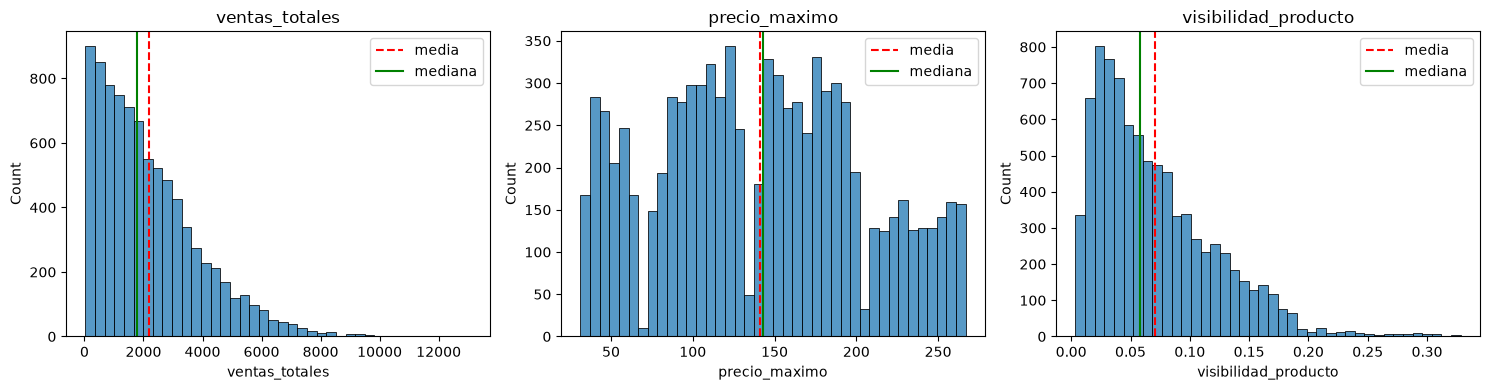

In [20]:
# Resumen univariado de las tres variables numéricas
numericas = ['ventas_totales', 'precio_maximo', 'visibilidad_producto']

resumen_num = pd.DataFrame({
    'media': df[numericas].mean(),
    'mediana': df[numericas].median(),
    'moda': [df[col].mode()[0] for col in numericas],
    'desviacion': df[numericas].std(),
    'Q1': df[numericas].quantile(0.25),
    'Q3': df[numericas].quantile(0.75),
})
resumen_num['IQR'] = resumen_num['Q3'] - resumen_num['Q1']
resumen_num['media/mediana'] = resumen_num['media'] / resumen_num['mediana']
resumen_num['sesgo'] = df[numericas].skew()
display(resumen_num.round(3))

# Histogramas
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
for eje, col in zip(ejes, numericas):
    sns.histplot(df[col], bins=40, ax=eje)
    eje.axvline(df[col].mean(), color='red', linestyle='--', label='media')
    eje.axvline(df[col].median(), color='green', linestyle='-', label='mediana')
    eje.set_title(col)
    eje.legend()
plt.tight_layout()
plt.show()

**Lectura:**
- **`ventas_totales`:** media 2.181, mediana 1.794, razón 1,22 y sesgo 1,18. Hay cola hacia la derecha: pocos productos venden mucho y suben el promedio. El producto típico vende cerca de 1.794, así que la mediana describe mejor.
- **`precio_maximo`:** media 141 y mediana 143 (razón 0,99). Es simétrica y la media sirve sin problema.
- **`visibilidad_producto`:** razón 1,22 y sesgo 1,21, también con cola a la derecha: pocos productos ocupan mucha góndola. La moda (0,122) no es confiable porque varios valores se repiten por el relleno de los ceros.

## Outliers con la regla 1.5 x IQR

Un valor es atípico si queda por debajo de `Q1 - 1.5 x IQR` o por encima de `Q3 + 1.5 x IQR`.

,limite inferior,limite superior,outliers,% del total
variable,,,,
ventas_totales,-2566.326,6501.870,186,2.182
precio_maximo,-43.899,323.370,0,0.000
visibilidad_producto,-0.069,0.198,142,1.666


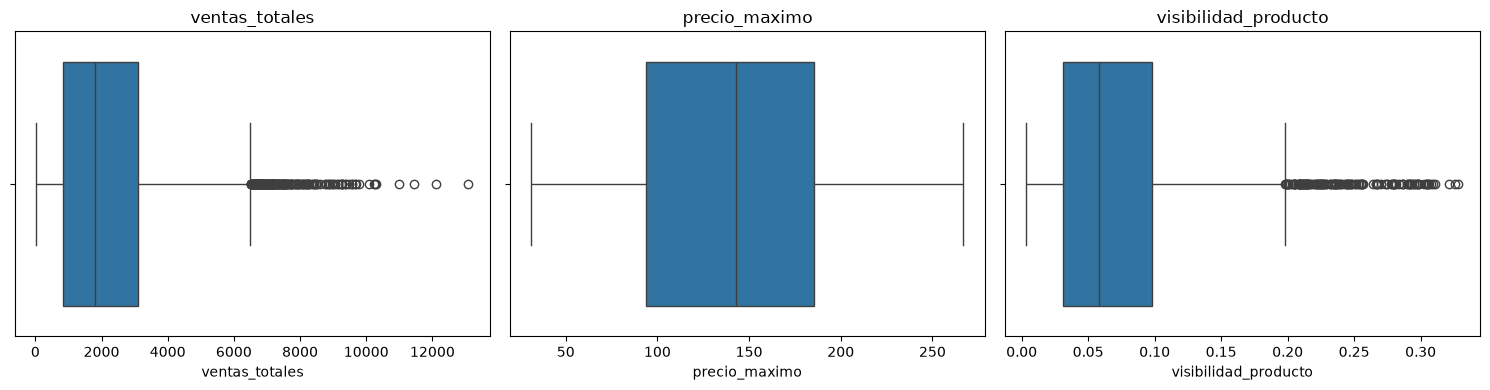

,outliers de ventas
tipo_tienda,
SUPERMERCADO TIPO 3,103
SUPERMERCADO TIPO 1,80
SUPERMERCADO TIPO 2,3


In [21]:
# Límites y conteo de outliers por variable
filas = []
for col in numericas:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    inferior, superior = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df[col] < inferior) | (df[col] > superior)).sum()
    filas.append({'variable': col, 'limite inferior': inferior, 'limite superior': superior,
                  'outliers': n, '% del total': n / len(df) * 100})
display(pd.DataFrame(filas).set_index('variable').round(3))

# Boxplots
fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
for eje, col in zip(ejes, numericas):
    sns.boxplot(x=df[col], ax=eje)
    eje.set_title(col)
plt.tight_layout()
plt.show()

# ¿Dónde están los outliers de ventas?
q1, q3 = df['ventas_totales'].quantile([0.25, 0.75])
limite_ventas = q3 + 1.5 * (q3 - q1)
display(df[df['ventas_totales'] > limite_ventas]['tipo_tienda'].value_counts().to_frame('outliers de ventas'))

**Lectura y decisión:**
- **`ventas_totales`:** 186 outliers (2,2 %). Se **conservan**: 183 están en supermercados tipo 1 y 3, que son las tiendas que más venden. Son ventas reales, no errores, y borrarlas dejaría fuera justo a las mejores tiendas.
- **`precio_maximo`:** 0 outliers.
- **`visibilidad_producto`:** 142 outliers (1,7 %). También se **conservan**: son productos con mucha góndola, un valor posible. Se tienen en cuenta al leer los promedios.

## Variables de texto: cuántos hay de cada categoría

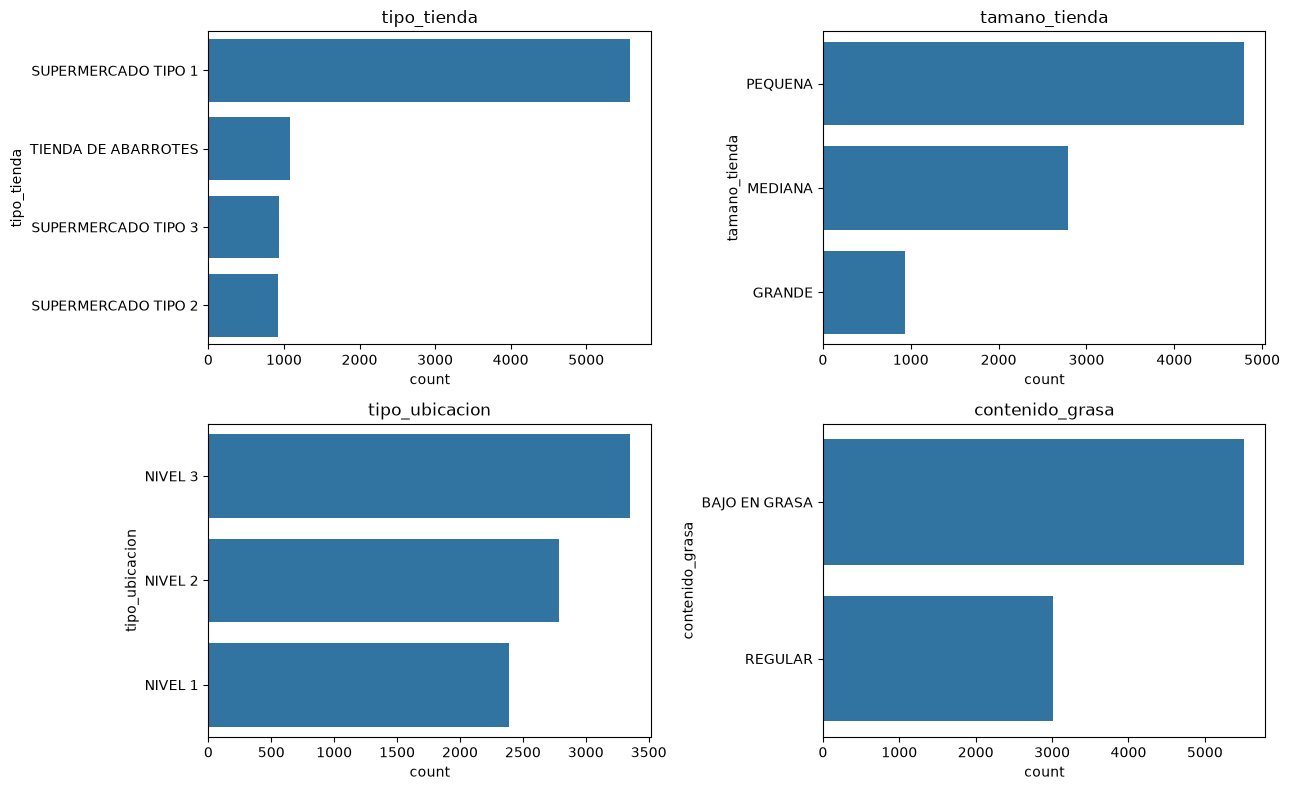

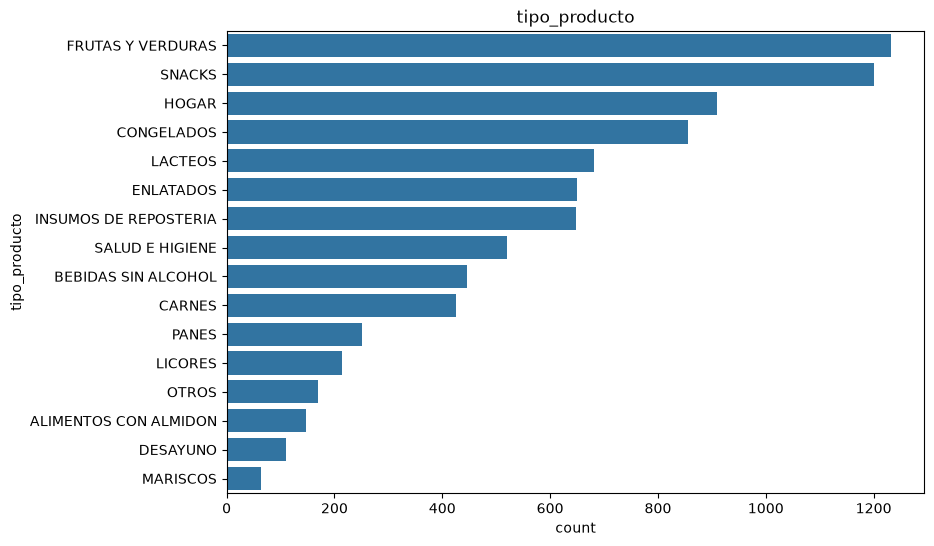

In [22]:
# Conteo de categorías (gráficos de barras)
categoricas = ['tipo_tienda', 'tamano_tienda', 'tipo_ubicacion', 'contenido_grasa']

fig, ejes = plt.subplots(2, 2, figsize=(13, 8))
for eje, col in zip(ejes.flat, categoricas):
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=eje)
    eje.set_title(col)
plt.tight_layout()
plt.show()

# tipo_producto tiene 16 categorías: va aparte
plt.figure(figsize=(9, 6))
sns.countplot(y='tipo_producto', data=df, order=df['tipo_producto'].value_counts().index)
plt.title('tipo_producto')
plt.show()

**Lectura:** el 65 % de las filas son de supermercados tipo 1, y las tiendas de abarrotes (1.083 filas) y los supermercados tipo 2 y 3 (unas 930 filas cada uno) son mucho menos. El tamaño mediano y el tipo de producto no pesan igual entre sí: las comparaciones de ventas hay que leerlas con eso en mente.

## GroupBy: ventas por grupo

Se compara `ventas_totales` entre las categorías de cada variable de texto: cuántas filas tiene el grupo, su media y su mediana.

In [23]:
# Ventas por grupo, para cada variable de texto
for col in ['tipo_tienda', 'tamano_tienda', 'tipo_ubicacion', 'contenido_grasa', 'tipo_producto']:
    tabla = (df.groupby(col)['ventas_totales']
               .agg(filas='size', media='mean', mediana='median')
               .sort_values('media', ascending=False).round(0))
    print(f"\nVentas por {col}")
    display(tabla)


Ventas por tipo_tienda


,filas,media,mediana
tipo_tienda,,,
SUPERMERCADO TIPO 3,935,3694.0,3365.0
SUPERMERCADO TIPO 1,5577,2316.0,1991.0
SUPERMERCADO TIPO 2,928,1995.0,1655.0
TIENDA DE ABARROTES,1083,340.0,257.0



Ventas por tamano_tienda


,filas,media,mediana
tamano_tienda,,,
MEDIANA,2793,2682.0,2251.0
GRANDE,932,2299.0,2051.0
PEQUENA,4798,1867.0,1484.0



Ventas por tipo_ubicacion


,filas,media,mediana
tipo_ubicacion,,,
NIVEL 2,2785,2324.0,2004.0
NIVEL 3,3350,2280.0,1812.0
NIVEL 1,2388,1877.0,1487.0



Ventas por contenido_grasa


,filas,media,mediana
contenido_grasa,,,
REGULAR,3006,2225.0,1845.0
BAJO EN GRASA,5517,2158.0,1765.0



Ventas por tipo_producto


,filas,media,mediana
tipo_producto,,,
ALIMENTOS CON ALMIDON,148,2374.0,1968.0
MARISCOS,64,2326.0,2055.0
FRUTAS Y VERDURAS,1232,2289.0,1831.0
SNACKS,1200,2277.0,1944.0
HOGAR,910,2259.0,1981.0
LACTEOS,682,2233.0,1651.0
ENLATADOS,649,2225.0,1860.0
PANES,251,2204.0,1860.0
CARNES,425,2159.0,1830.0


**Lectura:**
- **Tipo de tienda es lo que más separa las ventas:** supermercado tipo 3 vende en promedio 3.694 y las tiendas de abarrotes solo 340, más de 10 veces menos.
- **Tamaño y ubicación** separan menos y en orden raro (la tienda mediana vende más que la grande). Esto se debe a qué tiendas hay en cada grupo, no al tamaño en sí.
- **Tipo de producto y contenido de grasa** casi no cambian las ventas: todos los tipos de producto quedan entre 1.900 y 2.400.

## Dos variables a la vez: correlación y gráficos

Con variables numéricas se usa dispersión y correlación; con una numérica y una categórica, cajas.

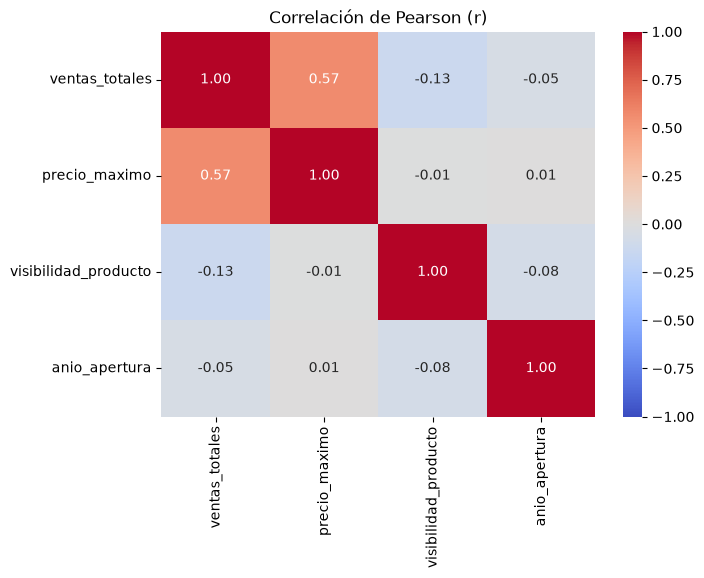

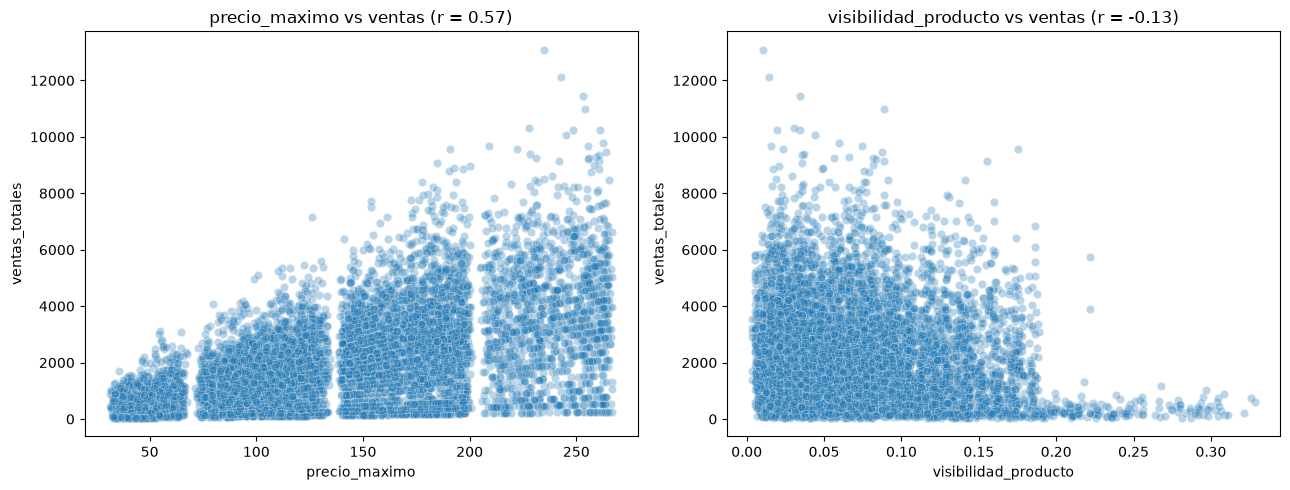

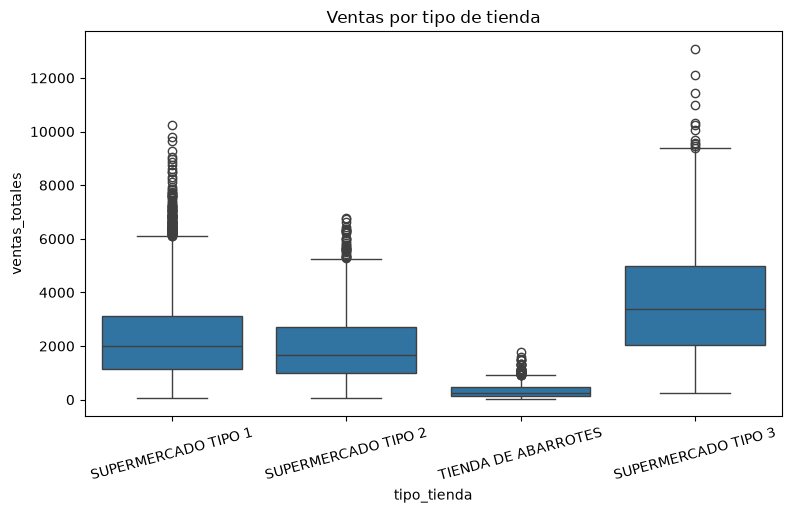

In [24]:
# Matriz de correlación entre las variables numéricas ya limpias
corr = df[['ventas_totales', 'precio_maximo', 'visibilidad_producto', 'anio_apertura']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de Pearson (r)')
plt.show()

# Precio y visibilidad frente a ventas
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for eje, col in zip(ejes, ['precio_maximo', 'visibilidad_producto']):
    sns.scatterplot(x=col, y='ventas_totales', data=df, alpha=0.3, ax=eje)
    eje.set_title(f"{col} vs ventas (r = {df[col].corr(df['ventas_totales']):.2f})")
plt.tight_layout()
plt.show()

# Ventas por tipo de tienda
plt.figure(figsize=(9, 5))
sns.boxplot(x='tipo_tienda', y='ventas_totales', data=df)
plt.xticks(rotation=15)
plt.title('Ventas por tipo de tienda')
plt.show()

**Lectura:**
- **Precio y ventas:** `r` = 0,57, relación positiva moderada. Los productos más caros venden más en total, pero con mucha dispersión.
- **Visibilidad y ventas:** `r` = -0,13, negativa y débil. Es raro (más góndola, menos ventas), y la paradoja de Simpson de abajo lo explica.
- **Año de apertura y ventas:** casi cero. Correlación no significa causa: un `r` alto solo indica que dos variables se mueven juntas.

## Chequeo de la paradoja de Simpson

Una relación puede verse de una manera con todos los datos juntos y cambiar al separar por grupos. Se calcula `r` con todos los datos y dentro de cada tipo de tienda, para precio y para visibilidad.

,r precio-ventas,r visibilidad-ventas,filas
TODAS LAS FILAS,0.568,-0.128,8523.0
SUPERMERCADO TIPO 1,0.683,-0.011,5577.0
SUPERMERCADO TIPO 2,0.670,0.006,928.0
SUPERMERCADO TIPO 3,0.737,-0.016,935.0
TIENDA DE ABARROTES,0.585,0.018,1083.0


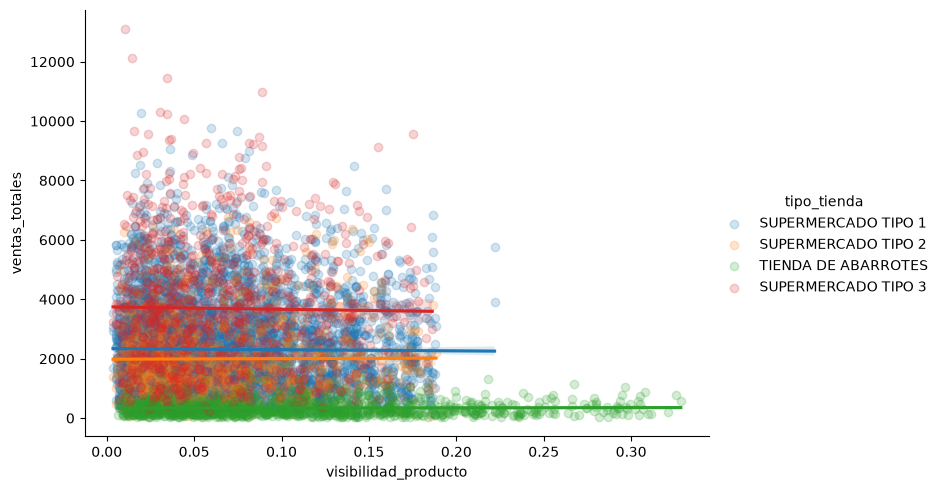

In [25]:
# r con todos los datos y dentro de cada tipo de tienda
filas = {'TODAS LAS FILAS': {
    'r precio-ventas': df['precio_maximo'].corr(df['ventas_totales']),
    'r visibilidad-ventas': df['visibilidad_producto'].corr(df['ventas_totales']),
    'filas': len(df)}}
for tienda, grupo in df.groupby('tipo_tienda'):
    filas[tienda] = {
        'r precio-ventas': grupo['precio_maximo'].corr(grupo['ventas_totales']),
        'r visibilidad-ventas': grupo['visibilidad_producto'].corr(grupo['ventas_totales']),
        'filas': len(grupo)}
display(pd.DataFrame(filas).T.round(3))

# Visibilidad vs ventas separado por tipo de tienda
sns.lmplot(x='visibilidad_producto', y='ventas_totales', hue='tipo_tienda',
           data=df, scatter_kws={'alpha': 0.2}, height=5, aspect=1.5)
plt.show()

**Lectura:** la relación de la visibilidad **cambia** al separar por tipo de tienda. Con todos los datos `r` = -0,13, pero dentro de cada tipo de tienda queda entre -0,02 y 0,02 (nula). Es la paradoja de Simpson. La variable que lo explica es `tipo_tienda`: las tiendas de abarrotes tienen más visibilidad (0,111 contra unos 0,065 en los supermercados) y ventas muy bajas (340), y eso arrastra la correlación general hacia abajo. La visibilidad no resta ventas por sí misma.

En cambio la relación de **precio y ventas se mantiene**: `r` entre 0,59 y 0,74 dentro de cada tipo de tienda, incluso más fuerte que la general (0,57). Esa relación sí es robusta.

## Conclusiones

1. **La limpieza no perdió filas** (8.523 antes y después). Se eliminó `peso_producto`, se unificaron las categorías de grasa, se rellenaron los nulos de `tamano_tienda` y se corrigieron 526 ceros de visibilidad.
2. **Las ventas tienen cola a la derecha.** La mediana (1.794) describe mejor al producto típico que la media (2.181). Los outliers de ventas son reales y se conservan.
3. **El tipo de tienda es el factor que más pesa:** un supermercado tipo 3 vende más de 10 veces lo que una tienda de abarrotes. El tipo de producto y la grasa casi no cambian las ventas.
4. **El precio se relaciona con las ventas de forma positiva y consistente** (`r` entre 0,57 y 0,74), también dentro de cada tipo de tienda.
5. **La visibilidad no explica las ventas.** La correlación negativa general (-0,13) desaparece al separar por tipo de tienda: es paradoja de Simpson, con `tipo_tienda` como variable confusora.

**Limitaciones:**
- El tamaño de `OUT017` y `OUT045` es una hipótesis, no un dato confirmado.
- Que los ceros de visibilidad sean datos no registrados es la explicación más probable, pero no se puede comprobar con el dataset.
- Todo es correlación: no demuestra que subir el precio o la visibilidad cause más ventas.